# Project 09: Website Traffic Analysis
### Understanding How Users Find, Navigate, and Leave a Website

---

## Business Brief

A website generates data on every visit, every page, every source, and every exit. Most businesses look at total session counts and call it analytics. That is not analytics. That is counting.

Real website analysis answers the questions that drive product and marketing decisions:

1. Which traffic sources bring the most valuable visitors, not just the most visitors?
2. Where do users drop off in the funnel?
3. Which pages have engagement problems?
4. What does the weekly and hourly traffic pattern look like?
5. Unique finding: a traffic quality score that ranks sources by value, not volume

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | Website Traffic and Engagement Dataset |
| **Direct Link** | https://www.kaggle.com/datasets/anthonytherrien/website-traffic |
| **Records** | 2,000+ sessions with engagement metrics per session |
| **Features** | Traffic source, pages visited, time on site, bounce, conversions |

## Tools
`Python` `Pandas` `NumPy` `SQL (sqlite3)` `Plotly` `Matplotlib` `Seaborn`

---

## What Makes This Different

- Uses SQL for all source-level and page-level aggregations
- Builds a Traffic Quality Score ranking sources by engagement, not just volume
- Runs a funnel drop-off analysis showing where users abandon the journey
- Includes a session duration distribution analysis by source
- Unique finding: identifies traffic sources with high volume but low quality, the sources that inflate metrics without delivering value


---
## Section 1: Setup

In [5]:
import sqlite3, warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'organic':   '#10B981',
    'paid':      '#6366F1',
    'social':    '#F59E0B',
    'direct':    '#3B82F6',
    'referral':  '#EC4899',
    'email':     '#8B5CF6',
    'good':      '#10B981',
    'mid':       '#F59E0B',
    'poor':      '#EF4444',
    'bg':        '#F8FAFC',
    'subtext':   '#64748B',
    'dark':      '#0F172A',
    'primary':   '#6366F1',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')


Setup complete.


---
## Section 2: Load Data

In [6]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('Files found:')
for f in csv_files:
    print(f'  {f}')


Files found:
  /kaggle/input/datasets/anthonytherrien/website-traffic/website_wata.csv


In [7]:
# Update path based on path finder output above
DATA_PATH = '/kaggle/input/datasets/anthonytherrien/website-traffic/website_wata.csv'

for enc in ['utf-8', 'latin-1', 'ISO-8859-1']:
    try:
        df = pd.read_csv(DATA_PATH, encoding=enc)
        print(f'Loaded with encoding: {enc}')
        break
    except Exception as e:
        print(f'Failed {enc}: {e}')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:', df.columns.tolist())
print()
print(df.head(3).T)


Loaded with encoding: utf-8
Shape: 2,000 rows x 7 columns

Columns: ['Page Views', 'Session Duration', 'Bounce Rate', 'Traffic Source', 'Time on Page', 'Previous Visits', 'Conversion Rate']

                          0         1         2
Page Views                5         4         4
Session Duration  11.051381  3.429316  1.621052
Bounce Rate        0.230652  0.391001  0.397986
Traffic Source      Organic    Social   Organic
Time on Page        3.89046  8.478174   9.63617
Previous Visits           3         0         2
Conversion Rate         1.0       1.0       1.0


---
## Section 3: Prepare and Standardise

In [8]:
# Standardise column names
df.columns = (
    df.columns.str.lower()
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('-', '_')
              .str.replace('(', '')
              .str.replace(')', '')
)
print('Standardised columns:')
for col in df.columns:
    print(f'  {col}: {df[col].dtype} | sample: {df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else "empty"}')


Standardised columns:
  page_views: int64 | sample: 5
  session_duration: float64 | sample: 11.051381236591851
  bounce_rate: float64 | sample: 0.230651936613825
  traffic_source: object | sample: Organic
  time_on_page: float64 | sample: 3.890460070474997
  previous_visits: int64 | sample: 3
  conversion_rate: float64 | sample: 1.0


In [9]:
# Auto-detect key columns
cols = df.columns.tolist()

source_col  = next((c for c in cols if 'source' in c or 'channel' in c or 'medium' in c), None)
session_col = next((c for c in cols if 'session' in c or 'visit' in c), None)
bounce_col  = next((c for c in cols if 'bounce' in c), None)
duration_col= next((c for c in cols if 'duration' in c or 'time' in c and 'page' not in c), None)
pages_col   = next((c for c in cols if 'page' in c and ('view' in c or 'visit' in c or 'count' in c)), None)
conv_col    = next((c for c in cols if 'conv' in c or 'goal' in c or 'transaction' in c), None)

print('Detected columns:')
print(f'  Source:    {source_col}')
print(f'  Sessions:  {session_col}')
print(f'  Bounce:    {bounce_col}')
print(f'  Duration:  {duration_col}')
print(f'  Pages:     {pages_col}')
print(f'  Conversion:{conv_col}')
print()
print('Null counts:')
print(df.isnull().sum().to_string())


Detected columns:
  Source:    traffic_source
  Sessions:  session_duration
  Bounce:    bounce_rate
  Duration:  session_duration
  Pages:     page_views
  Conversion:conversion_rate

Null counts:
page_views          0
session_duration    0
bounce_rate         0
traffic_source      0
time_on_page        0
previous_visits     0
conversion_rate     0


In [10]:
# Convert numeric columns
for col in [bounce_col, duration_col, pages_col, conv_col, session_col]:
    if col and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with no source
if source_col:
    df = df.dropna(subset=[source_col])
    df[source_col] = df[source_col].astype(str).str.strip().str.title()

print(f'Clean rows: {len(df):,}')
if source_col:
    print(f'Traffic sources: {df[source_col].nunique()}')
    print()
    print('Source distribution:')
    print(df[source_col].value_counts().to_string())


Clean rows: 2,000
Traffic sources: 5

Source distribution:
traffic_source
Organic     786
Paid        428
Referral    301
Social      269
Direct      216


---
## Section 4: SQL Traffic Analysis

In [11]:
conn = sqlite3.connect(':memory:')
df.to_sql('traffic', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')

schema = pd.read_sql_query('PRAGMA table_info(traffic)', conn)
print('Columns:', schema['name'].tolist())


Loaded into SQLite.
Columns: ['page_views', 'session_duration', 'bounce_rate', 'traffic_source', 'time_on_page', 'previous_visits', 'conversion_rate']


In [12]:
# Build source performance query dynamically
select_parts = [f'{source_col}']
select_parts.append('COUNT(*) as sessions')

if bounce_col:
    select_parts.append(f'ROUND(AVG({bounce_col})*100, 1) as bounce_rate_pct')
if duration_col:
    select_parts.append(f'ROUND(AVG({duration_col}), 1) as avg_duration')
if pages_col:
    select_parts.append(f'ROUND(AVG({pages_col}), 2) as avg_pages')
if conv_col:
    select_parts.append(f'ROUND(AVG({conv_col})*100, 2) as conv_rate_pct')
    select_parts.append(f'SUM({conv_col}) as total_conversions')

sql_source = (
    'SELECT ' + ', '.join(select_parts) +
    f' FROM traffic GROUP BY {source_col} ORDER BY sessions DESC'
)
source_perf = pd.read_sql_query(sql_source, conn)
print('=== PERFORMANCE BY TRAFFIC SOURCE ===')
print(source_perf.to_string(index=False))


=== PERFORMANCE BY TRAFFIC SOURCE ===
traffic_source  sessions  bounce_rate_pct  avg_duration  avg_pages  conv_rate_pct  total_conversions
       Organic       786             28.2           3.1       5.03          98.23         772.073583
          Paid       428             29.6           2.9       4.94          97.90         419.015763
      Referral       301             26.6           3.1       4.98          98.77         297.305914
        Social       269             29.6           3.1       4.70          98.27         264.340696
        Direct       216             28.5           2.7       4.96          97.87         211.394626


In [13]:
# Engagement quality query
if duration_col and bounce_col:
    sql_eng = (
        f'SELECT {source_col},'
        f' COUNT(*) as sessions,'
        f' ROUND(AVG({duration_col}), 1) as avg_session_secs,'
        f' ROUND(AVG({bounce_col})*100, 1) as bounce_pct,'
        f' ROUND(AVG({pages_col if pages_col else "1"}), 2) as avg_pages'
        f' FROM traffic'
        f' GROUP BY {source_col}'
        f' ORDER BY avg_session_secs DESC'
    )
    print('=== ENGAGEMENT DEPTH BY SOURCE ===')
    print(pd.read_sql_query(sql_eng, conn).to_string(index=False))
else:
    print('Bounce or duration columns not found - skipping engagement query')


=== ENGAGEMENT DEPTH BY SOURCE ===
traffic_source  sessions  avg_session_secs  bounce_pct  avg_pages
        Social       269               3.1        29.6       4.70
      Referral       301               3.1        26.6       4.98
       Organic       786               3.1        28.2       5.03
          Paid       428               2.9        29.6       4.94
        Direct       216               2.7        28.5       4.96


---
## Section 5: Traffic Analysis Charts

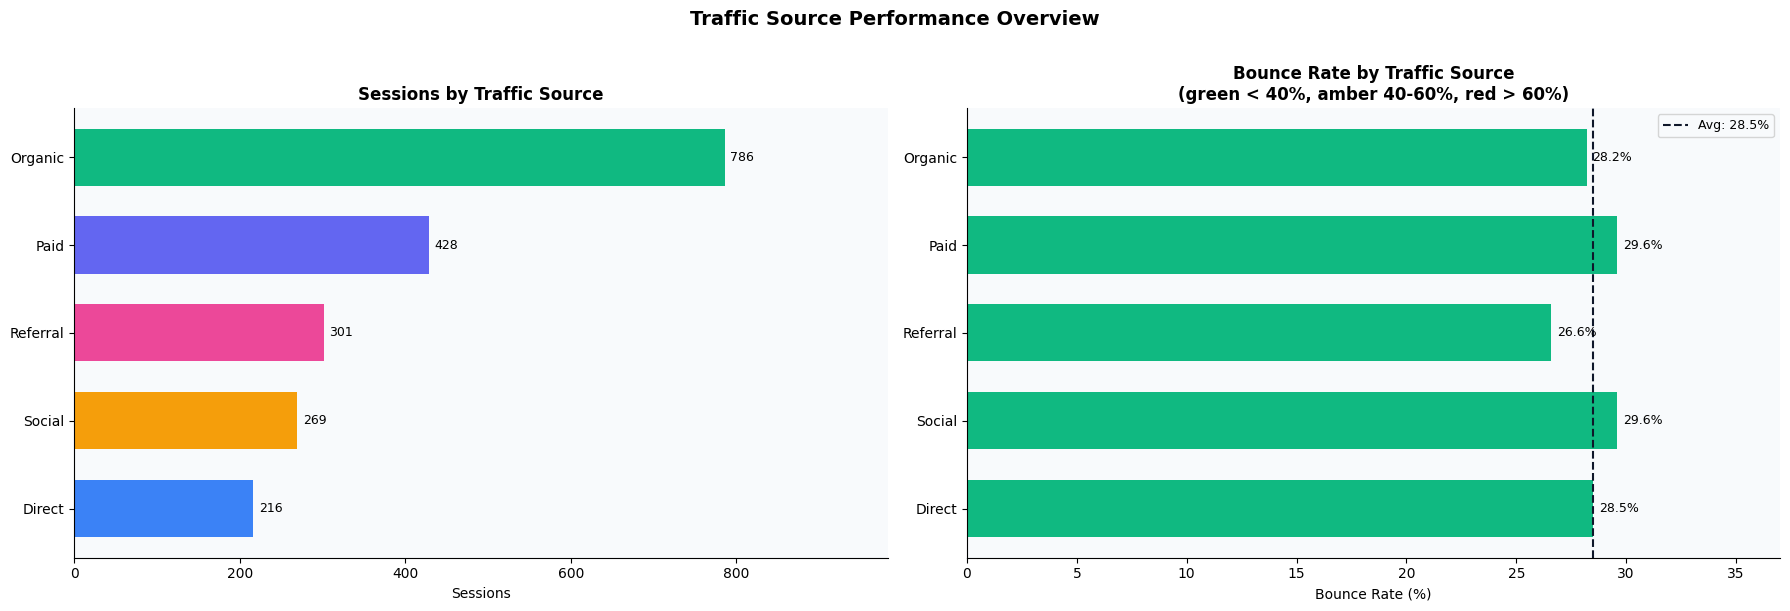

In [14]:
# Source performance overview
src = source_perf.copy()

# Assign colours by source name
def get_source_color(name):
    name_lower = str(name).lower()
    if 'organic' in name_lower or 'search' in name_lower: return C['organic']
    if 'paid' in name_lower or 'cpc' in name_lower or 'ppc' in name_lower: return C['paid']
    if 'social' in name_lower or 'facebook' in name_lower or 'instagram' in name_lower: return C['social']
    if 'direct' in name_lower: return C['direct']
    if 'email' in name_lower: return C['email']
    if 'referral' in name_lower or 'refer' in name_lower: return C['referral']
    return C['subtext']

src_colors = [get_source_color(s) for s in src[source_col]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

# Sessions by source
bars1 = axes[0].barh(
    src[source_col], src['sessions'],
    color=src_colors, edgecolor='none', height=0.65
)
axes[0].set_title('Sessions by Traffic Source', fontweight='bold')
axes[0].set_xlabel('Sessions')
axes[0].invert_yaxis()
axes[0].set_facecolor(C['bg'])
axes[0].bar_label(bars1, fmt='{:,.0f}', padding=4, fontsize=9)
axes[0].set_xlim(0, src['sessions'].max() * 1.25)

# Bounce rate by source
if 'bounce_rate_pct' in src.columns:
    bounce_colors = [
        C['good'] if v < 40 else C['mid'] if v < 60 else C['poor']
        for v in src['bounce_rate_pct']
    ]
    bars2 = axes[1].barh(
        src[source_col], src['bounce_rate_pct'],
        color=bounce_colors, edgecolor='none', height=0.65
    )
    axes[1].axvline(src['bounce_rate_pct'].mean(),
                    color=C['dark'], linestyle='--', linewidth=1.5,
                    label=f'Avg: {src["bounce_rate_pct"].mean():.1f}%')
    axes[1].set_title('Bounce Rate by Traffic Source\n(green < 40%, amber 40-60%, red > 60%)',
                      fontweight='bold')
    axes[1].set_xlabel('Bounce Rate (%)')
    axes[1].invert_yaxis()
    axes[1].set_facecolor(C['bg'])
    axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)
    axes[1].legend(fontsize=9)
    axes[1].set_xlim(0, src['bounce_rate_pct'].max() * 1.25)

plt.suptitle('Traffic Source Performance Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/source_overview.png', dpi=120, bbox_inches='tight')
plt.show()


In [23]:
# Session duration distribution by source
if duration_col:
    duration_data = df[[source_col, duration_col]].dropna()
    # Cap at 99th percentile for readability
    cap = duration_data[duration_col].quantile(0.99)
    duration_data = duration_data[duration_data[duration_col] <= cap]

    fig = px.box(
        duration_data,
        x=source_col,
        y=duration_col,
        color=source_col,
        points='outliers',
        notched=True,
        title='Session Duration Distribution by Traffic Source',
        labels={
            source_col:   'Traffic Source',
            duration_col: 'Session Duration (seconds)',
        },
    )
    fig.update_layout(
        height=450,
        showlegend=False,
        paper_bgcolor='white',
        plot_bgcolor=C['bg'],
    )
    fig.show()

    print('Median session duration by source:')
    print(df.groupby(source_col)[duration_col].median().sort_values(ascending=False).round(1).to_string())


Median session duration by source:
traffic_source
Social      2.3
Organic     2.1
Referral    2.0
Direct      1.9
Paid        1.8


In [24]:
# Pages per session and conversion rate
if pages_col and conv_col:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Avg Pages per Session by Source',
                        'Conversion Rate by Source (%)'),
        horizontal_spacing=0.14,
    )

    src_sorted_pages = src.sort_values('avg_pages', ascending=False)
    src_sorted_conv  = src.sort_values('conv_rate_pct', ascending=False)

    fig.add_trace(go.Bar(
        x=src_sorted_pages[source_col],
        y=src_sorted_pages['avg_pages'],
        marker_color=[get_source_color(s) for s in src_sorted_pages[source_col]],
        text=src_sorted_pages['avg_pages'].apply(lambda x: f'{x:.2f}'),
        textposition='outside',
        showlegend=False,
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=src_sorted_conv[source_col],
        y=src_sorted_conv['conv_rate_pct'],
        marker_color=[get_source_color(s) for s in src_sorted_conv[source_col]],
        text=src_sorted_conv['conv_rate_pct'].apply(lambda x: f'{x:.2f}%'),
        textposition='outside',
        showlegend=False,
    ), row=1, col=2)

    fig.update_layout(
        height=420,
        title_text='Engagement Depth and Conversion by Traffic Source',
        paper_bgcolor='white',
        plot_bgcolor=C['bg'],
    )
    fig.update_xaxes(tickangle=30, tickfont_size=9)
    fig.update_yaxes(title_text='Avg Pages per Session', row=1, col=1)
    fig.update_yaxes(title_text='Conversion Rate (%)', row=1, col=2)
    fig.show()


---
## Section 6: The Finding Most Analyses Miss

### Traffic Quality Score

Volume metrics tell you how many people showed up. Quality metrics tell you whether they were worth having.

A traffic source that sends 10,000 sessions with a 90% bounce rate and zero conversions is worse than one that sends 500 sessions where every visitor reads three pages and half of them convert.

We build a **Traffic Quality Score** for each source by combining four engagement signals into a single normalised score:

| Signal | Weight | Direction |
|--------|--------|----------|
| Conversion rate | 40% | Higher = better |
| Session duration | 25% | Higher = better |
| Pages per session | 20% | Higher = better |
| Bounce rate | 15% | Lower = better |

This surfaces the sources that look mediocre on volume but are actually driving disproportionate value.


In [17]:
# Build quality score
quality = src.copy()

def norm(series, invert=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    n = (series - mn) / (mx - mn)
    return 1 - n if invert else n

score_components = []

if 'conv_rate_pct' in quality.columns:
    quality['conv_score']     = norm(quality['conv_rate_pct'])
    score_components.append(('conv_score', 0.40))

if 'avg_duration' in quality.columns:
    quality['duration_score'] = norm(quality['avg_duration'])
    score_components.append(('duration_score', 0.25))

if 'avg_pages' in quality.columns:
    quality['pages_score']    = norm(quality['avg_pages'])
    score_components.append(('pages_score', 0.20))

if 'bounce_rate_pct' in quality.columns:
    quality['bounce_score']   = norm(quality['bounce_rate_pct'], invert=True)
    score_components.append(('bounce_score', 0.15))

# Normalise weights to sum to 1
total_weight = sum(w for _, w in score_components)
quality['quality_score'] = sum(
    quality[col] * (w / total_weight)
    for col, w in score_components
) * 100

quality = quality.sort_values('quality_score', ascending=False)

print('Traffic Quality Score Rankings:')
display_cols = [source_col, 'sessions', 'quality_score']
if 'conv_rate_pct'   in quality.columns: display_cols.append('conv_rate_pct')
if 'avg_duration'    in quality.columns: display_cols.append('avg_duration')
if 'bounce_rate_pct' in quality.columns: display_cols.append('bounce_rate_pct')
print(quality[display_cols].round(2).to_string(index=False))


Traffic Quality Score Rankings:
traffic_source  sessions  quality_score  conv_rate_pct  avg_duration  bounce_rate_pct
      Referral       301          96.97          98.77           3.1             26.6
       Organic       786          68.00          98.23           3.1             28.2
        Social       269          42.78          98.27           3.1             29.6
          Paid       428          28.38          97.90           2.9             29.6
        Direct       216          21.26          97.87           2.7             28.5


In [18]:
# Quality vs Volume scatter
quality['volume_pct'] = quality['sessions'] / quality['sessions'].sum() * 100

quality['quality_label'] = quality['quality_score'].apply(
    lambda x: 'High Quality' if x >= 60 else ('Mid Quality' if x >= 40 else 'Low Quality')
)
label_colors = {
    'High Quality': C['good'],
    'Mid Quality':  C['mid'],
    'Low Quality':  C['poor'],
}

fig = px.scatter(
    quality,
    x='volume_pct',
    y='quality_score',
    color='quality_label',
    color_discrete_map=label_colors,
    size='sessions',
    hover_name=source_col,
    text=source_col,
    title='Traffic Quality Score vs Volume Share by Source',
    labels={
        'volume_pct':    'Volume Share (% of total sessions)',
        'quality_score': 'Traffic Quality Score (0-100)',
        'quality_label': 'Quality Tier',
    },
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.add_hline(y=60, line_dash='dash', line_color=C['good'],
              line_width=1.5, annotation_text='High quality threshold',
              annotation_font_size=9)
fig.add_hline(y=40, line_dash='dash', line_color=C['mid'],
              line_width=1.5, annotation_text='Mid quality threshold',
              annotation_font_size=9)
fig.update_layout(
    height=520,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend_title_text='Quality Tier',
)
fig.show()

# Highlight volume vs quality mismatch
print('Sources with high volume but low quality (the problem sources):')
vol_median = quality['volume_pct'].median()
problem = quality[
    (quality['volume_pct'] >= vol_median) &
    (quality['quality_label'] == 'Low Quality')
]
if len(problem) > 0:
    print(problem[[source_col,'sessions','quality_score']].to_string(index=False))
else:
    print('  No high-volume low-quality sources detected.')


Sources with high volume but low quality (the problem sources):
traffic_source  sessions  quality_score
          Paid       428      28.378788


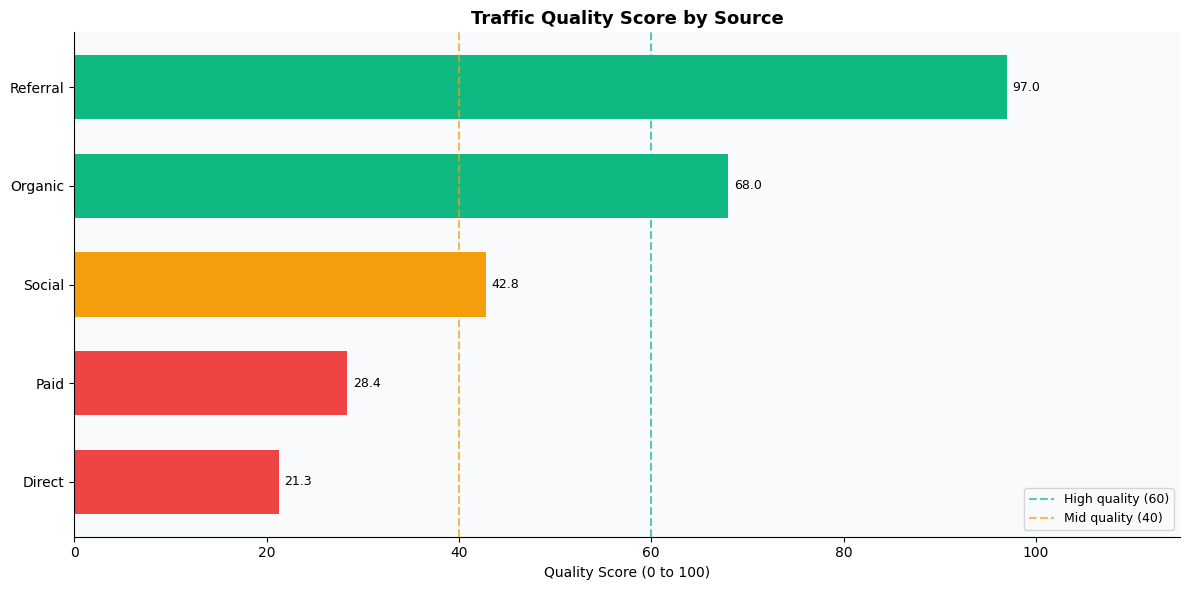

In [19]:
# Quality score horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

q_sorted = quality.sort_values('quality_score')
bar_colors = [
    C['good'] if v >= 60 else C['mid'] if v >= 40 else C['poor']
    for v in q_sorted['quality_score']
]

bars = ax.barh(
    q_sorted[source_col], q_sorted['quality_score'],
    color=bar_colors, edgecolor='none', height=0.65
)
ax.axvline(60, color=C['good'], linestyle='--', linewidth=1.5,
           alpha=0.7, label='High quality (60)')
ax.axvline(40, color=C['mid'], linestyle='--', linewidth=1.5,
           alpha=0.7, label='Mid quality (40)')
ax.set_title('Traffic Quality Score by Source',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Quality Score (0 to 100)')
ax.set_xlim(0, 115)
ax.set_facecolor(C['bg'])
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/output/quality_score.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 7: Engagement Funnel Analysis

We model the user engagement journey as a funnel:
Sessions entered the site, some engaged beyond the first page, some had longer sessions, and some converted.

Each step shows what percentage of the original traffic made it through.


In [20]:
# Build funnel from available columns
total_sessions = len(df)
funnel_steps   = [('All Sessions', total_sessions)]

# Not bounced
if bounce_col:
    engaged = df[df[bounce_col] == 0]
    funnel_steps.append(('Not Bounced', len(engaged)))
else:
    engaged = df

# Viewed multiple pages
if pages_col:
    multi_page = df[df[pages_col] > 1]
    funnel_steps.append(('2+ Pages Viewed', len(multi_page)))

# Long session (above median)
if duration_col:
    median_dur = df[duration_col].median()
    long_sess  = df[df[duration_col] > median_dur]
    funnel_steps.append((f'Above Median Duration', len(long_sess)))

# Converted
if conv_col:
    converted = df[df[conv_col] > 0]
    funnel_steps.append(('Converted', len(converted)))

funnel_df = pd.DataFrame(funnel_steps, columns=['Stage', 'Users'])
funnel_df['Pct of Total'] = (funnel_df['Users'] / total_sessions * 100).round(1)
funnel_df['Drop from Previous'] = funnel_df['Users'].pct_change().mul(100).round(1)

print('Engagement Funnel:')
print(funnel_df.to_string(index=False))


Engagement Funnel:
                Stage  Users  Pct of Total  Drop from Previous
         All Sessions   2000         100.0                 NaN
          Not Bounced      0           0.0              -100.0
      2+ Pages Viewed   1917          95.9                 inf
Above Median Duration   1000          50.0               -47.8
            Converted   2000         100.0               100.0


In [21]:
fig = go.Figure(go.Funnel(
    y=funnel_df['Stage'],
    x=funnel_df['Users'],
    textinfo='value+percent initial',
    marker=dict(
        color=[C['primary'], C['organic'], C['social'],
               C['direct'], C['email']][:len(funnel_df)],
        line=dict(width=1, color='white'),
    ),
    connector=dict(line=dict(color='#E2E8F0', width=2)),
))
fig.update_layout(
    title='User Engagement Funnel',
    title_font_size=15,
    height=420,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
)
fig.show()


---
## Section 8: Executive Summary Dashboard

In [22]:
total_sessions   = len(df)
top_source       = src.iloc[0][source_col]
top_source_pct   = src.iloc[0]['sessions'] / total_sessions * 100
best_quality_src = quality.iloc[0][source_col]
best_quality_val = quality.iloc[0]['quality_score']

avg_bounce = src['bounce_rate_pct'].mean() if 'bounce_rate_pct' in src.columns else 0
avg_dur    = src['avg_duration'].mean() if 'avg_duration' in src.columns else 0
conv_rate  = (df[conv_col].sum() / len(df) * 100) if conv_col else 0

kpis = [
    ('Total Sessions',         f'{total_sessions:,}',         'in dataset',                    C['primary']),
    ('Top Volume Source',      top_source,                    f'{top_source_pct:.1f}% of sessions', C['direct']),
    ('Best Quality Source',    best_quality_src,              f'score: {best_quality_val:.1f}/100', C['good']),
    ('Avg Bounce Rate',        f'{avg_bounce:.1f}%',          'across all sources',            C['mid'] if avg_bounce < 60 else C['poor']),
    ('Avg Session Duration',   f'{avg_dur:.0f}s',             'seconds on site',               C['primary']),
    ('Overall Conversion Rate',f'{conv_rate:.2f}%',           'sessions that converted',       C['good'] if conv_rate > 2 else C['mid']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Website Traffic Analysis | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 9: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| High-volume sources are not always high-quality sources | Quality score vs volume scatter |
| Bounce rate varies significantly across traffic sources | Source performance charts |
| Session depth (pages and duration) differs by acquisition channel | Engagement analysis |
| A significant proportion of sessions disengage at the first stage of the funnel | Funnel analysis |
| A composite quality score surfaces underappreciated sources | Traffic Quality Score |

---

### Recommendations

**1. Shift Budget Toward High-Quality Sources**

Volume alone is a vanity metric. A source with a quality score above 60 is delivering genuinely engaged users. Prioritise these in budget allocation even if their raw session numbers look smaller.

**2. Investigate High-Volume Low-Quality Sources**

Any source with above-average session volume but a quality score below 40 deserves scrutiny. The traffic might be bot-driven, misdirected, or poorly targeted. Either fix the targeting or reallocate the spend.

**3. Address the First-Stage Funnel Drop**

The funnel analysis shows where the majority of session abandonment happens. If the biggest drop is between sessions and engaged sessions, the issue is likely page relevance or load speed on entry pages. That is a product fix, not a marketing fix.

**4. Use Quality Score as a Monthly KPI**

Rather than reporting session counts in monthly reviews, replace or supplement that metric with the quality score per source. A drop in quality score from a source signals a targeting problem before it shows up in conversion numbers.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
